# TVL 企業排球聯賽 — 賽果預測與特徵重要性分析

本 Notebook 建構一個機器學習模型，基於球隊單場團隊數據預測比賽勝負，
並透過 SHAP 特徵重要性分析，找出影響企業排球聯賽勝負的關鍵數據指標。

**流程概覽：**
1. 資料準備：從 SQLite 讀取球員單場數據 → 聚合為球隊團隊數據
2. 勝負標籤推論：利用同日對戰組合的總得分比較，推論勝 (1) / 敗 (0)
3. 模型訓練：RandomForest + XGBoost 分類器
4. SHAP 特徵重要性分析
5. 模型匯出

## 0. 環境設定與套件匯入

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import shap
import joblib

# 中文字型設定（避免圖表亂碼）
matplotlib.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

# 隨機種子，確保可重現性
SEED = 42
np.random.seed(SEED)

print("環境設定完成。")

環境設定完成。


---
## 1. 資料準備與聚合 (Data Prep)

### 1.1 連線資料庫，讀取原始數據

將 `player_match_stats` JOIN `players` 與 `teams`，取得每位球員的 `team_id`、`gender`、`team_name`。

In [2]:
DB_PATH = Path("../data/db/tvl_database.db")

conn = sqlite3.connect(DB_PATH)

player_stats = pd.read_sql_query("""
    SELECT s.stat_id, s.player_id, s.match_date, s.opponent,
           s.sets_played, s.attack_total, s.attack_points,
           s.block_points, s.serve_total, s.serve_points,
           s.receive_total, s.receive_excellent,
           s.dig_total, s.dig_excellent,
           s.set_total, s.set_excellent,
           s.total_points,
           p.team_id, p.gender, p.position,
           t.team_name
    FROM player_match_stats s
    JOIN players p ON s.player_id = p.player_id
    JOIN teams   t ON p.team_id = t.team_id AND p.gender = t.gender
""", conn)

conn.close()

print(f"原始球員單場紀錄數：{len(player_stats)}")
print(f"涵蓋球隊數：{player_stats['team_id'].nunique()}")
print(f"涵蓋比賽日數：{player_stats['match_date'].nunique()}")
player_stats.head(3)

原始球員單場紀錄數：3485
涵蓋球隊數：6
涵蓋比賽日數：36


,stat_id,player_id,match_date,opponent,sets_played,attack_total,attack_points,block_points,serve_total,serve_points,...,receive_excellent,dig_total,dig_excellent,set_total,set_excellent,total_points,team_id,gender,position,team_name
0,1,1,2025-11-01,雲林美津濃,3,1,1,0,10,0,...,0,1,0,81,36,1,1,M,S,台灣電力公司男子排球隊
1,2,1,2025-11-02,臺北國北獅,5,1,1,1,18,1,...,0,7,4,107,72,3,1,M,S,台灣電力公司男子排球隊
2,3,1,2025-11-08,獅子王,4,1,1,1,22,0,...,0,8,2,96,16,2,1,M,S,台灣電力公司男子排球隊


### 1.2 聚合為「球隊單場團隊數據」

將球員層級資料以 `groupby(['match_date', 'team_id', 'gender', 'team_name', 'opponent'])` 聚合，
計算該隊在該場比賽中的攻守數據總和。

In [3]:
team_match = (
    player_stats
    .groupby(["match_date", "team_id", "gender", "team_name", "opponent"])
    .agg(
        total_attack_pts=("attack_points", "sum"),
        total_attack_tot=("attack_total", "sum"),
        total_block_pts=("block_points", "sum"),
        total_serve_pts=("serve_points", "sum"),
        total_serve_tot=("serve_total", "sum"),
        total_rcv_exc=("receive_excellent", "sum"),
        total_rcv_tot=("receive_total", "sum"),
        total_dig_exc=("dig_excellent", "sum"),
        total_dig_tot=("dig_total", "sum"),
        total_set_exc=("set_excellent", "sum"),
        total_set_tot=("set_total", "sum"),
        total_points=("total_points", "sum"),
        # sets_played: 取同隊球員最大值（替補球員可能局數較少）
        total_sets=("sets_played", "max"),
        n_players=("player_id", "count"),
    )
    .reset_index()
)

print(f"球隊單場紀錄數：{len(team_match)}")
team_match.head(3)

球隊單場紀錄數：216


,match_date,team_id,gender,team_name,opponent,total_attack_pts,total_attack_tot,total_block_pts,total_serve_pts,total_serve_tot,total_rcv_exc,total_rcv_tot,total_dig_exc,total_dig_tot,total_set_exc,total_set_tot,total_points,total_sets,n_players
0,2025-11-01,1,M,台灣電力公司男子排球隊,雲林美津濃,37,92,6,1,64,33,59,8,12,36,81,44,3,16
1,2025-11-01,2,M,美津濃男子排球隊,屏東台電,44,87,7,4,76,35,49,5,11,35,77,55,3,16
2,2025-11-01,3,F,臺北鯨華女子排球隊,高雄台電,62,161,3,2,94,35,70,22,65,45,119,67,4,16


### 1.3 特徵工程 (Feature Engineering)

計算五大團隊效率指標：

| 特徵 | 定義 | 排球意義 |
|------|------|----------|
| **ASR** | 攻擊得分 / 攻擊總數 × 100 | 團隊攻擊成功率 |
| **GP%** | 接發好球 / 接發總數 × 100 | 團隊接發到位率 |
| **DIG%** | 防守好球 / 防守總數 × 100 | 團隊防守起球率 |
| **BLK/Set** | 攔網得分 / 總局數 | 團隊局均攔網 |
| **ACE%** | 發球得分 / 發球總數 × 100 | 團隊發球破壞率 |

In [4]:
def safe_pct(num, denom):
    """安全百分比計算，分母為 0 時回傳 0.0。"""
    return (num / denom * 100) if denom > 0 else 0.0


team_match["ASR"] = team_match.apply(
    lambda r: safe_pct(r["total_attack_pts"], r["total_attack_tot"]), axis=1
)
team_match["GP_pct"] = team_match.apply(
    lambda r: safe_pct(r["total_rcv_exc"], r["total_rcv_tot"]), axis=1
)
team_match["DIG_pct"] = team_match.apply(
    lambda r: safe_pct(r["total_dig_exc"], r["total_dig_tot"]), axis=1
)
team_match["BLK_per_set"] = team_match.apply(
    lambda r: r["total_block_pts"] / r["total_sets"] if r["total_sets"] > 0 else 0,
    axis=1,
)
team_match["ACE_pct"] = team_match.apply(
    lambda r: safe_pct(r["total_serve_pts"], r["total_serve_tot"]), axis=1
)

# 快速檢視特徵分佈
FEATURE_COLS = ["ASR", "GP_pct", "DIG_pct", "BLK_per_set", "ACE_pct"]
team_match[FEATURE_COLS].describe().round(2)

,ASR,GP_pct,DIG_pct,BLK_per_set,ACE_pct
count,216.00,216.00,216.00,216.00,216.00
mean,41.77,49.97,31.82,1.86,4.00
std,8.72,17.00,14.01,0.90,2.83
min,19.53,8.77,0.00,0.00,0.00
25%,35.74,38.64,21.79,1.25,1.92
50%,41.74,52.79,30.86,1.71,3.88
75%,47.72,62.36,40.96,2.33,5.48
max,65.67,87.76,71.43,4.67,17.57


### 1.4 勝負標籤推論 (Win/Loss Label Inference)

**關鍵挑戰：** 資料庫中沒有明確的勝負欄位 (`win`/`loss`)，需要自行推論。

**推論邏輯：**
1. 透過「對手簡稱 → team_id」映射表，配對同一天的兩支對戰隊伍
2. 比較兩隊的團隊總得分 (`total_points`)，得分較高者標記為勝 (1)，較低者為敗 (0)
3. 若雙方總得分相同（極罕見），該場比賽不納入訓練集

> **注意：** 排球比賽中，勝隊的團隊總得分不一定高於敗隊（例如 3:2 的比賽中，
> 敗方可能在輸掉的兩局中得到高分）。此處以總得分作為近似標籤，
> 是在缺乏局比分資料時的務實做法，應留意此 proxy label 的局限性。

In [5]:
# 對手簡稱 → (team_id, gender) 映射
OPP_SHORT_TO_TEAM = {
    "屏東台電":   (1, "M"),
    "雲林美津濃": (2, "M"),
    "臺北國北獅": (4, "M"),
    "桃園臺產":   (5, "M"),
    "獅子王":     (7, "M"),
    "高雄台電":   (4, "F"),
    "臺北鯨華":   (3, "F"),
    "新北中纖":   (5, "F"),
    "義力營造":   (7, "F"),
}

# 建立以 (match_date, team_id, gender) 為 key 的快速查找表
team_pts_lookup = (
    team_match
    .set_index(["match_date", "team_id", "gender"])["total_points"]
    .to_dict()
)

labels = []
for _, row in team_match.iterrows():
    opp_info = OPP_SHORT_TO_TEAM.get(row["opponent"])
    if opp_info is None:
        labels.append(np.nan)
        continue

    opp_team_id, opp_gender = opp_info
    opp_key = (row["match_date"], opp_team_id, opp_gender)
    opp_pts = team_pts_lookup.get(opp_key)

    if opp_pts is None:
        labels.append(np.nan)
    elif row["total_points"] > opp_pts:
        labels.append(1)  # 勝
    elif row["total_points"] < opp_pts:
        labels.append(0)  # 敗
    else:
        labels.append(np.nan)  # 平手，排除

team_match["win"] = labels

# 移除無法推論勝負的紀錄
labeled = team_match.dropna(subset=["win"]).copy()
labeled["win"] = labeled["win"].astype(int)

print(f"成功標記勝負的比賽紀錄數：{len(labeled)}")
print(f"  勝場數：{labeled['win'].sum()}")
print(f"  敗場數：{(labeled['win'] == 0).sum()}")
print(f"  勝率分佈：{labeled['win'].mean():.1%}")
print(f"\n排除的紀錄數（無法配對或平手）：{len(team_match) - len(labeled)}")

成功標記勝負的比賽紀錄數：212
  勝場數：106
  敗場數：106
  勝率分佈：50.0%

排除的紀錄數（無法配對或平手）：4


In [6]:
# 快速檢視：勝/敗兩組的特徵分佈差異
print("=== 勝場平均 ===")
print(labeled[labeled["win"] == 1][FEATURE_COLS].mean().round(2))
print("\n=== 敗場平均 ===")
print(labeled[labeled["win"] == 0][FEATURE_COLS].mean().round(2))

=== 勝場平均 ===
ASR            45.86
GP_pct         50.83
DIG_pct        33.76
BLK_per_set     2.25
ACE_pct         4.30
dtype: float64

=== 敗場平均 ===
ASR            37.53
GP_pct         49.38
DIG_pct        30.17
BLK_per_set     1.44
ACE_pct         3.75
dtype: float64


---
## 2. 模型訓練與評估 (Model Training)

### 2.1 建立特徵矩陣與目標變數

使用五大團隊效率指標作為特徵，勝負作為二元目標變數。

In [7]:
X = labeled[FEATURE_COLS].values
y = labeled["win"].values

print(f"特徵矩陣 X shape: {X.shape}")
print(f"目標變數 y shape: {y.shape}")
print(f"正例 (勝) 比例: {y.mean():.1%}")

特徵矩陣 X shape: (212, 5)
目標變數 y shape: (212,)
正例 (勝) 比例: 50.0%


### 2.2 切分訓練集與測試集

使用 80/20 分層抽樣，確保訓練集與測試集的勝負比例一致。

> **注意：** 由於樣本數有限，同時使用 5-fold 交叉驗證評估模型穩定性。

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"訓練集：{X_train.shape[0]} 筆 (勝 {y_train.sum()} / 敗 {(y_train == 0).sum()})")
print(f"測試集：{X_test.shape[0]} 筆 (勝 {y_test.sum()} / 敗 {(y_test == 0).sum()})")

訓練集：169 筆 (勝 85 / 敗 84)
測試集：43 筆 (勝 21 / 敗 22)


### 2.3 模型一：Random Forest

先以 Random Forest 作為 baseline，觀察特徵是否具有區分力。

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=3,
    random_state=SEED,
    class_weight="balanced",
)
rf_model.fit(X_train, y_train)

# 交叉驗證（5-fold）
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rf_cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring="f1")

print("=== Random Forest ====")
print(f"5-Fold CV F1-score: {rf_cv_scores.mean():.3f} (+/- {rf_cv_scores.std():.3f})")
print(f"\n--- 測試集評估 ---")
rf_pred = rf_model.predict(X_test)
print(classification_report(y_test, rf_pred, target_names=["敗 (0)", "勝 (1)"]))

=== Random Forest ====
5-Fold CV F1-score: 0.685 (+/- 0.073)

--- 測試集評估 ---
              precision    recall  f1-score   support

       敗 (0)       0.73      0.86      0.79        22
       勝 (1)       0.82      0.67      0.74        21

    accuracy                           0.77        43
   macro avg       0.78      0.77      0.76        43
weighted avg       0.78      0.77      0.76        43



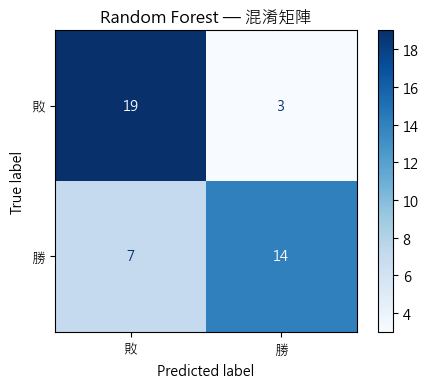

In [10]:
# Random Forest 混淆矩陣
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=["敗", "勝"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Random Forest — 混淆矩陣")
plt.tight_layout()
plt.show()

### 2.4 模型二：XGBoost

使用 XGBoost 梯度提升樹，通常在結構化數據上表現優於 Random Forest。

In [11]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=SEED,
    eval_metric="logloss",
    use_label_encoder=False,
)
xgb_model.fit(X_train, y_train)

# 交叉驗證
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring="f1")

print("=== XGBoost ====")
print(f"5-Fold CV F1-score: {xgb_cv_scores.mean():.3f} (+/- {xgb_cv_scores.std():.3f})")
print(f"\n--- 測試集評估 ---")
xgb_pred = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_pred, target_names=["敗 (0)", "勝 (1)"]))

c:\Users\User\.conda\envs\pytorch\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:55:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\User\.conda\envs\pytorch\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:55:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\User\.conda\envs\pytorch\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:55:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\User\.conda\envs\pytorch\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:55:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encode

=== XGBoost ====
5-Fold CV F1-score: 0.717 (+/- 0.083)

--- 測試集評估 ---
              precision    recall  f1-score   support

       敗 (0)       0.73      0.73      0.73        22
       勝 (1)       0.71      0.71      0.71        21

    accuracy                           0.72        43
   macro avg       0.72      0.72      0.72        43
weighted avg       0.72      0.72      0.72        43



c:\Users\User\.conda\envs\pytorch\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:55:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


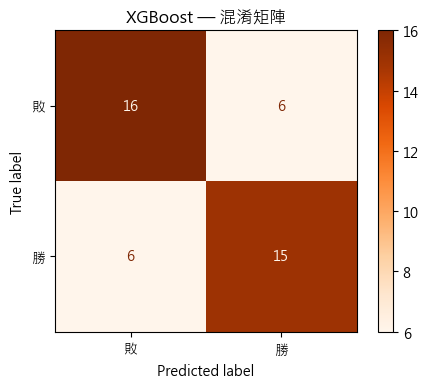

In [12]:
# XGBoost 混淆矩陣
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_pred,
    display_labels=["敗", "勝"],
    cmap="Oranges",
    ax=ax,
)
ax.set_title("XGBoost — 混淆矩陣")
plt.tight_layout()
plt.show()

### 2.5 模型比較摘要

In [13]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "CV F1 (mean)": [rf_cv_scores.mean(), xgb_cv_scores.mean()],
    "CV F1 (std)": [rf_cv_scores.std(), xgb_cv_scores.std()],
    "Test Accuracy": [
        (rf_pred == y_test).mean(),
        (xgb_pred == y_test).mean(),
    ],
}).round(3)

print("=== 模型比較 ===")
print(comparison.to_string(index=False))

# 選擇較優的模型進行後續 SHAP 分析
if xgb_cv_scores.mean() >= rf_cv_scores.mean():
    best_model = xgb_model
    best_name = "XGBoost"
else:
    best_model = rf_model
    best_name = "Random Forest"

print(f"\n選擇 {best_name} 進行 SHAP 分析與匯出。")

=== 模型比較 ===
        Model  CV F1 (mean)  CV F1 (std)  Test Accuracy
Random Forest         0.685        0.073          0.767
      XGBoost         0.717        0.083          0.721

選擇 XGBoost 進行 SHAP 分析與匯出。


---
## 3. 特徵重要性分析 (Feature Importance)

### 3.1 內建特徵重要性

先觀察模型內建的 feature importance（基於分裂增益）。

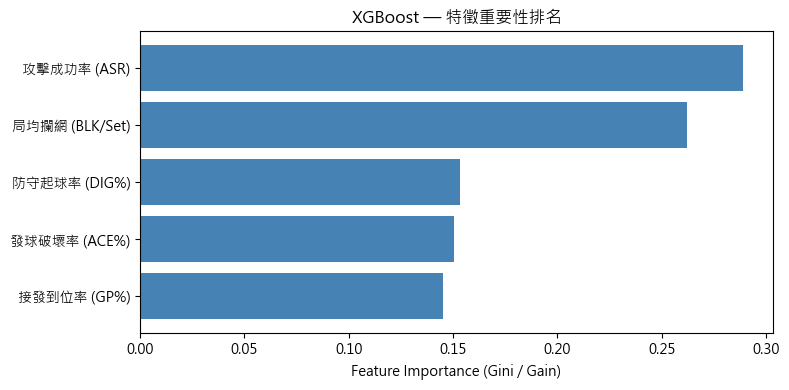

In [14]:
# 中文特徵名稱對照
FEATURE_LABELS = {
    "ASR": "攻擊成功率 (ASR)",
    "GP_pct": "接發到位率 (GP%)",
    "DIG_pct": "防守起球率 (DIG%)",
    "BLK_per_set": "局均攔網 (BLK/Set)",
    "ACE_pct": "發球破壞率 (ACE%)",
}
feature_labels_list = [FEATURE_LABELS[c] for c in FEATURE_COLS]

importances = best_model.feature_importances_
imp_df = pd.DataFrame({
    "feature": feature_labels_list,
    "importance": importances,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_df["feature"], imp_df["importance"], color="steelblue")
ax.set_xlabel("Feature Importance (Gini / Gain)")
ax.set_title(f"{best_name} — 特徵重要性排名")
plt.tight_layout()
plt.show()

### 3.2 SHAP 分析

使用 SHAP (SHapley Additive exPlanations) 計算每個特徵對預測結果的邊際貢獻，
相比內建 feature importance，SHAP 可以顯示特徵值的方向性影響（正/負貢獻）。

In [15]:
# 建立 SHAP Explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

# 對於二元分類，XGBoost 的 shap_values 為單一陣列；
# RandomForest 可能回傳 list[ndarray]，取正類 (index=1)
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]  # 正類 (勝) 的 SHAP values
else:
    shap_values_plot = shap_values

print(f"SHAP values shape: {shap_values_plot.shape}")

SHAP values shape: (212, 5)


C:\Users\User\AppData\Local\Temp\ipykernel_1788\1371793357.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


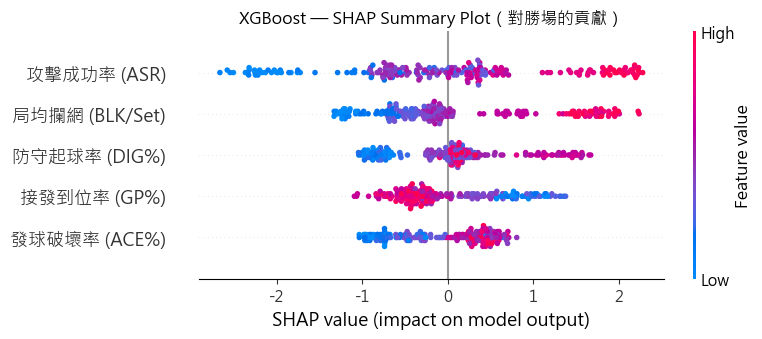

In [16]:
# SHAP Summary Plot (Beeswarm)
# 顯示每個特徵對「勝 (1)」預測的貢獻方向與強度
plt.figure(figsize=(10, 5))
shap.summary_plot(
    shap_values_plot,
    features=X,
    feature_names=feature_labels_list,
    show=False,
)
plt.title(f"{best_name} — SHAP Summary Plot（對勝場的貢獻）")
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_1788\3141162802.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


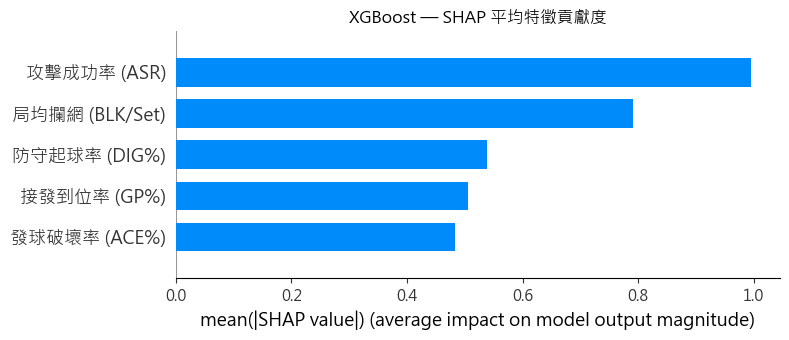

In [17]:
# SHAP Bar Plot（平均絕對 SHAP 值排名）
plt.figure(figsize=(8, 4))
shap.summary_plot(
    shap_values_plot,
    features=X,
    feature_names=feature_labels_list,
    plot_type="bar",
    show=False,
)
plt.title(f"{best_name} — SHAP 平均特徵貢獻度")
plt.tight_layout()
plt.show()

In [18]:
# 列出前三大關鍵指標
mean_abs_shap = np.abs(shap_values_plot).mean(axis=0)
top3_idx = np.argsort(mean_abs_shap)[::-1][:3]

print("=" * 50)
print("影響 TVL 企業排球聯賽勝負的前三大關鍵數據指標：")
print("=" * 50)
for rank, idx in enumerate(top3_idx, 1):
    print(f"  {rank}. {feature_labels_list[idx]}")
    print(f"     平均 |SHAP|: {mean_abs_shap[idx]:.4f}")
print("=" * 50)

影響 TVL 企業排球聯賽勝負的前三大關鍵數據指標：
  1. 攻擊成功率 (ASR)
     平均 |SHAP|: 0.9959
  2. 局均攔網 (BLK/Set)
     平均 |SHAP|: 0.7911
  3. 防守起球率 (DIG%)
     平均 |SHAP|: 0.5385


---
## 4. 模型匯出 (Model Export)

將訓練好的最佳模型匯出為 `.pkl`，供儀表板或其他應用載入使用。

In [19]:
MODEL_DIR = Path("../src/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "match_predictor.pkl"

# 儲存模型與特徵名稱，方便後續載入時對照
artifact = {
    "model": best_model,
    "model_name": best_name,
    "feature_cols": FEATURE_COLS,
    "feature_labels": feature_labels_list,
    "training_samples": len(labeled),
    "cv_f1_mean": (
        xgb_cv_scores.mean() if best_name == "XGBoost" else rf_cv_scores.mean()
    ),
}

joblib.dump(artifact, model_path)

# 驗證載入
loaded = joblib.load(model_path)
print(f"模型已儲存至：{model_path.resolve()}")
print(f"模型類型：{loaded['model_name']}")
print(f"特徵欄位：{loaded['feature_cols']}")
print(f"訓練樣本數：{loaded['training_samples']}")
print(f"CV F1-score: {loaded['cv_f1_mean']:.3f}")
print(f"檔案大小：{model_path.stat().st_size / 1024:.1f} KB")

模型已儲存至：D:\Tommy\TVL-Analysis\src\models\match_predictor.pkl
模型類型：XGBoost
特徵欄位：['ASR', 'GP_pct', 'DIG_pct', 'BLK_per_set', 'ACE_pct']
訓練樣本數：212
CV F1-score: 0.717
檔案大小：196.1 KB


---
## 5. 結論與後續方向

### 本次分析摘要

- 成功從球員單場數據聚合出球隊團隊層級的 5 大效率特徵
- 透過總得分比較推論勝負標籤（proxy label），建立二元分類模型
- 使用 SHAP 分析找出影響勝負的關鍵指標排名

### 已知限制

1. **Proxy Label 偏差**：以總得分推論勝負並非 100% 準確，3:2 的比賽中敗方總得分可能更高
2. **樣本量有限**：單一賽季的比賽場數有限，模型泛化能力需持續觀察
3. **特徵遺漏**：未納入對手實力、主客場、賽程疲勞度等因素

### 後續可改進方向

- 引入外部 API 取得實際局比分，建立真實勝負標籤
- 加入「對手特徵差異」（如雙方 ASR 差值）作為進階特徵
- 隨賽季累積更多數據後，重新訓練並觀察特徵重要性變化
- 嘗試時間序列模型（如滑動窗口特徵），捕捉球隊近期狀態